# ***IRIS VERİ SETİ KULLANILARAK SINIFLANDIRMA - YAPAY SİNİR AĞI MODELİ OLUŞTURULACAK***

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import time
import warnings
warnings.filterwarnings("ignore")

In [ ]:
dfC = pd.read_csv('/content/Iris.csv')

In [ ]:
df = dfC.copy()

In [ ]:
df.head(3)

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa


In [ ]:
df.tail(3)

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
147,148,6.5,3.0,5.2,2.0,Iris-virginica
148,149,6.2,3.4,5.4,2.3,Iris-virginica
149,150,5.9,3.0,5.1,1.8,Iris-virginica


# ***MAKİNE ÖĞRENİMİ KISMI***

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, recall_score, f1_score, confusion_matrix, roc_auc_score, log_loss

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB


In [ ]:
df = df.drop(columns= ["Id"])

In [ ]:
df.head(3)

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species_Iris-versicolor,Species_Iris-virginica
0,5.1,3.5,1.4,0.2,False,False
1,4.9,3.0,1.4,0.2,False,False
2,4.7,3.2,1.3,0.2,False,False


In [ ]:
y = df[["Species"]]
x = df.drop(["Species"], axis=1)

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(x,y, random_state=42, test_size=0.30)

In [ ]:
standart = StandardScaler()

In [ ]:
x_train_scaler = standart.fit_transform(x_train)
x_test_scaler = standart.transform(x_test)

In [ ]:
start_train_time = time.time()
kn = KNeighborsClassifier()
model = kn.fit(x_train_scaler, y_train)
end_train_time = time.time()
total_train_time = end_train_time - start_train_time            #KNeighborsClassifier

y_train_pred = kn.predict(x_train_scaler)
y_train_proba = kn.predict_proba(x_train_scaler)[:, 1]
train_accuracy = accuracy_score(y_train, y_train_pred)
train_recall = recall_score(y_train, y_train_pred, average='weighted')
train_f1 = f1_score(y_train, y_train_pred, average='weighted')
train_confusion = confusion_matrix(y_train, y_train_pred)


start_test_time = time.time()
y_test_pred = kn.predict(x_test_scaler)
y_test_proba = kn.predict_proba(x_test_scaler)[:, 1]
end_test_time = time.time()
total_test_time = end_test_time - start_test_time

test_accuracy = accuracy_score(y_test, y_test_pred)
test_recall = recall_score(y_test, y_test_pred, average='weighted')
test_f1 = f1_score(y_test, y_test_pred, average='weighted')
test_confusion = confusion_matrix(y_test, y_test_pred)


print(f"Train Time : {total_train_time}")
print(f"Train Accuracy Score: {train_accuracy}")
print(f"Train Recall Score : {train_recall}")
print(f"Train F1 Score : {train_f1}")
print(f"Train Confusion Matrix : {train_confusion}")
print("---------------------------------------------------------")
print(f"Test Time : {total_test_time}")
print(f"Test Accuracy Score: {test_accuracy}")
print(f"Test Recall Score: {test_recall}")
print(f"Test F1 Score: {test_f1}")
print(f"Test Confusion Matrix: {test_confusion}")

Train Time : 0.0030782222747802734
Train Accuracy Score: 0.9523809523809523
Train Recall Score : 0.9523809523809523
Train F1 Score : 0.9523722548380082
Train Confusion Matrix : [[31  0  0]
 [ 0 35  2]
 [ 0  3 34]]
---------------------------------------------------------
Test Time : 0.0034132003784179688
Test Accuracy Score: 1.0
Test Recall Score: 1.0
Test F1 Score: 1.0
Test Confusion Matrix: [[19  0  0]
 [ 0 13  0]
 [ 0  0 13]]


In [ ]:
start_train_time = time.time()
rf = RandomForestClassifier()
model = rf.fit(x_train_scaler, y_train)
end_train_time = time.time()
total_train_time = end_train_time - start_train_time            #RandomForestClassifier

y_train_pred = rf.predict(x_train_scaler)
y_train_proba = rf.predict_proba(x_train_scaler)[:, 1]
train_accuracy = accuracy_score(y_train, y_train_pred)
train_recall = recall_score(y_train, y_train_pred, average='weighted')
train_f1 = f1_score(y_train, y_train_pred, average='weighted')
train_confusion = confusion_matrix(y_train, y_train_pred)


start_test_time = time.time()
y_test_pred = rf.predict(x_test_scaler)
y_test_proba = rf.predict_proba(x_test_scaler)[:, 1]
end_test_time = time.time()
total_test_time = end_test_time - start_test_time

test_accuracy = accuracy_score(y_test, y_test_pred)
test_recall = recall_score(y_test, y_test_pred, average='weighted')
test_f1 = f1_score(y_test, y_test_pred, average='weighted')
test_confusion = confusion_matrix(y_test, y_test_pred)


print(f"Train Time : {total_train_time}")
print(f"Train Accuracy Score: {train_accuracy}")
print(f"Train Recall Score : {train_recall}")
print(f"Train F1 Score : {train_f1}")
print(f"Train Confusion Matrix : {train_confusion}")
print("---------------------------------------------------------")
print(f"Test Time : {total_test_time}")
print(f"Test Accuracy Score: {test_accuracy}")
print(f"Test Recall Score: {test_recall}")
print(f"Test F1 Score: {test_f1}")
print(f"Test Confusion Matrix: {test_confusion}")

Train Time : 0.1641080379486084
Train Accuracy Score: 1.0
Train Recall Score : 1.0
Train F1 Score : 1.0
Train Confusion Matrix : [[31  0  0]
 [ 0 37  0]
 [ 0  0 37]]
---------------------------------------------------------
Test Time : 0.01545572280883789
Test Accuracy Score: 1.0
Test Recall Score: 1.0
Test F1 Score: 1.0
Test Confusion Matrix: [[19  0  0]
 [ 0 13  0]
 [ 0  0 13]]


# ***DERİN ÖĞRENME***

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.preprocessing import LabelEncoder

In [ ]:
le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train.values.ravel())
y_test_encoded = le.transform(y_test.values.ravel())

In [ ]:
X_train_tensor = torch.FloatTensor(x_train_scaler)
X_test_tensor = torch.FloatTensor(x_test_scaler)
y_train_tensor = torch.LongTensor(y_train_encoded)
y_test_tensor = torch.LongTensor(y_test_encoded)

In [ ]:
class IrisNet(nn.Module):
    def __init__(self):
        super(IrisNet, self).__init__()
        self.fc1 = nn.Linear(4, 16)

        self.relu = nn.ReLU()

    def forward(self, x):
        out = self.fc1(x)
        out = self.relu(out)
        out = self.fc2(out)
        return out

model = IrisNet()

In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

In [ ]:
epochs = 100
for epoch in range(epochs):

    outputs = model(X_train_tensor)
    loss = criterion(outputs, y_train_tensor)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

In [ ]:
model.eval()
with torch.no_grad():
    test_outputs = model(X_test_tensor)

    _, y_pred_tensor = torch.max(test_outputs, 1)

y_pred = y_pred_tensor.numpy()

In [ ]:
ann_accuracy = accuracy_score(y_test_encoded, y_pred)
print(f"Yapay Sinir Ağı (PyTorch) Test Accuracy Skoru: {ann_accuracy:.4f}")

Yapay Sinir Ağı (PyTorch) Test Accuracy Skoru: 1.0000


# ***MNIST VERİ SETİ İLE SİNİR AĞI OLUŞTURULACAK***

In [4]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Dropout
import cv2

In [3]:
from tensorflow.keras.datasets import mnist

In [5]:
(x_train, y_train), (x_test, y_test) = mnist.load_data()  #veri setini yükleme

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [6]:
x_train = x_train / 255.0
x_test = x_test / 255.0   #veri setini normalize ediyoruz

In [7]:
model = Sequential([
    Flatten(input_shape=(28, 28)),
    Dense(128, activation='relu'),
    Dropout(0.2),
    Dense(10, activation='softmax')
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])                                    #model oluşturulması

In [8]:
print("Model eğitiliyor...")
model.fit(x_train, y_train, epochs=5)

print("\nModel test ediliyor...")
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=2)
print(f"Test doğruluğu (Accuracy): {test_acc:.4f}")

Model eğitiliyor...
Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 14s 6ms/step - accuracy: 0.8640 - loss: 0.4767
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9580 - loss: 0.1458
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9680 - loss: 0.1045
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9731 - loss: 0.0871
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9781 - loss: 0.0708

Model test ediliyor...
313/313 - 1s - 3ms/step - accuracy: 0.9767 - loss: 0.0782
Test doğruluğu (Accuracy): 0.9767


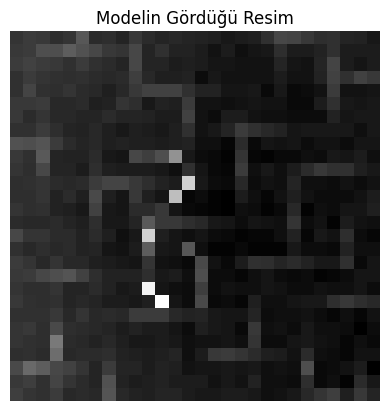

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step

--- SONUÇ ---
Modelin Tahmini: 2
Emin Olma Oranı (Güven): %97.90


In [12]:
def tahmin_et(resim_yolu):

    img = cv2.imread(resim_yolu, cv2.IMREAD_GRAYSCALE)

    if img is None:
        print("Resim bulunamadı! Lütfen dosyanın '/content/' klasöründe olduğundan emin olun.")
        return

    img_resized = cv2.resize(img, (28, 28))

    img_inverted = cv2.bitwise_not(img_resized)

    img_normalized = img_inverted / 255.0
    img_final = np.expand_dims(img_normalized, axis=0)

    plt.imshow(img_inverted, cmap='gray')
    plt.title("Modelin Gördüğü Resim")
    plt.axis('off')
    plt.show()

    tahmin_dizisi = model.predict(img_final)
    tahmin_edilen_rakam = np.argmax(tahmin_dizisi)
    guven_orani = np.max(tahmin_dizisi) * 100

    print(f"\n--- SONUÇ ---")
    print(f"Modelin Tahmini: {tahmin_edilen_rakam}")
    print(f"Emin Olma Oranı (Güven): %{guven_orani:.2f}")

tahmin_et("/content/dosyaSayi.jpeg")